In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
os.makedirs("../results/01", exist_ok = True)

In [15]:
df = pd.read_csv("../data/raw/TPD_OPEN_DATA_ReportedCrimesPublicDash.csv", low_memory = False)
print(df.shape)
df.head()

(251280, 14)


,IncidentID,DateOccurred,Year,Month,Day,TimeOccur,Division,Ward,UCR,UCRDescription,Offense,OffenseDescription,CallSource,ESRI_OID
0,112318516Z,2022/01/01 07:00:00+00,2022,January,Sat,00:23,West,NaN,6,06 - LARCENY,603,Larceny - Shoplifting,Web Reported,1
1,009240162Z,2022/03/01 20:00:00+00,2022,March,Tue,13:32,West,1.0,2,02 - SEXUAL ASSAULT,203,Sexual Assault - Attempted Rape Female/Male,NaN,2
2,1210180043,2019/02/12 10:00:00+00,2019,February,Tue,0302,South,5.0,1,01 - HOMICIDE,101,Criminal Homicide - Murder,NaN,3
3,1801010290,2018/01/01 17:00:00+00,2018,January,Mon,1053,West,1.0,7,07 - GTA,701,Motor Vehicle Theft - Stolen and/or Recovered ...,Call For Service,4
4,1801010146,2018/01/01 11:00:00+00,2018,January,Mon,0428,South,5.0,4,"04 - ASSAULT, AGGRAVATED",403,Aggravated Assault - Other,Call For Service,5


In [16]:
df.dtypes

IncidentID             object
DateOccurred           object
Year                    int64
Month                  object
Day                    object
TimeOccur              object
Division               object
Ward                  float64
UCR                     int64
UCRDescription         object
Offense                 int64
OffenseDescription     object
CallSource             object
ESRI_OID                int64
dtype: object

In [17]:
df.isnull().sum()

IncidentID                0
DateOccurred              0
Year                      0
Month                     0
Day                       0
TimeOccur                 0
Division               3743
Ward                  15566
UCR                       0
UCRDescription            0
Offense                   0
OffenseDescription        0
CallSource             7408
ESRI_OID                  0
dtype: int64

In [18]:
df.nunique()

IncidentID            219176
DateOccurred           63435
Year                       9
Month                     12
Day                        7
TimeOccur               2941
Division                   5
Ward                       6
UCR                        8
UCRDescription             8
Offense                   37
OffenseDescription        37
CallSource                 4
ESRI_OID              251280
dtype: int64

In [19]:
df.describe()

,Year,Ward,UCR,Offense,ESRI_OID
count,251280.000000,235714.000000,251280.000000,251280.000000,251280.000000
mean,2021.600466,3.562113,5.679310,572.111847,125640.500000
std,2.317427,1.812803,0.995473,99.509593,72538.432158
min,2018.000000,1.000000,1.000000,101.000000,1.000000
25%,2020.000000,2.000000,6.000000,603.000000,62820.750000
50%,2022.000000,3.000000,6.000000,603.000000,125640.500000
75%,2024.000000,5.000000,6.000000,606.000000,188460.250000
max,2026.000000,6.000000,8.000000,805.000000,251280.000000


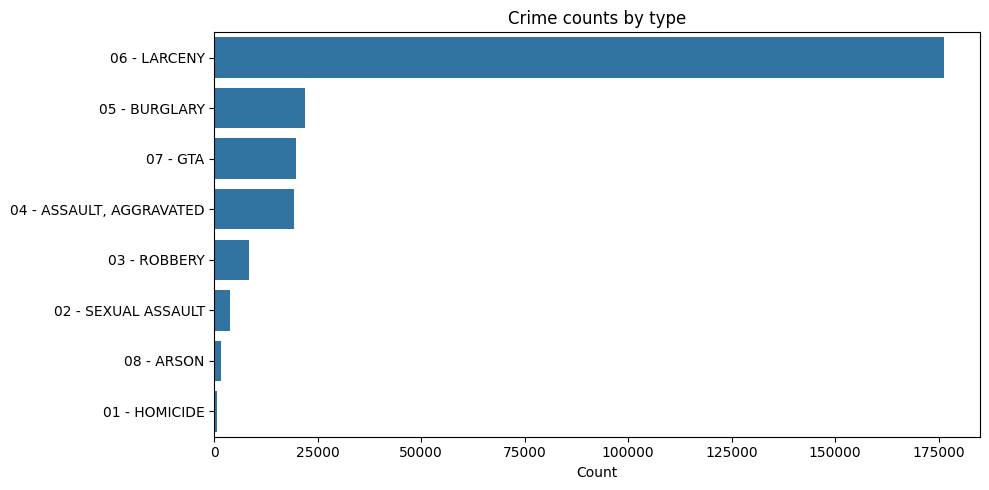

In [20]:
plt.figure(figsize = (10, 5))
order = df["UCRDescription"].value_counts().index
sns.countplot(data = df, y = "UCRDescription", order = order)
plt.title("Crime counts by type")
plt.xlabel("Count")
plt.ylabel("")
plt.tight_layout()
plt.savefig("../results/01/crime_counts_by_type.png", dpi = 150, bbox_inches = "tight")
plt.show()

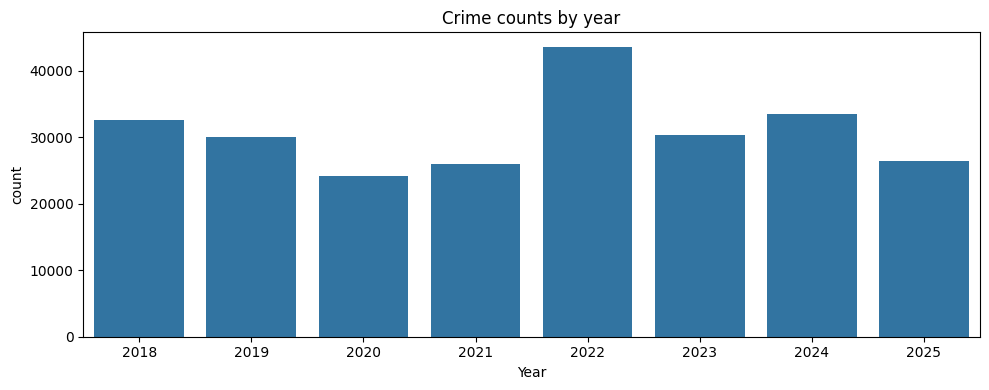

In [21]:
plt.figure(figsize = (10, 4))
sns.countplot(data = df[df["Year"] != 2026], x = "Year")
plt.title("Crime counts by year")
plt.tight_layout()
plt.savefig("../results/01/crime_counts_by_year.png", dpi = 150, bbox_inches = "tight")
plt.show()

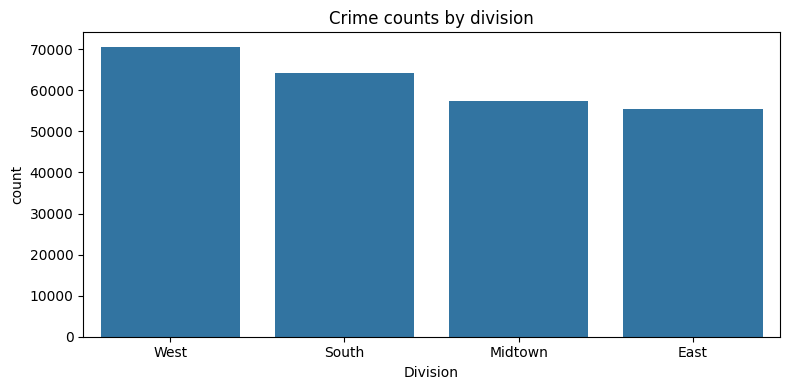

In [22]:
df_plot = df[df["Division"] != "Other Jurisdiction"]
order = df_plot["Division"].value_counts().index

plt.figure(figsize = (8, 4))
sns.countplot(data = df_plot, x = "Division", order = order)
plt.title("Crime counts by division")
plt.tight_layout()
plt.savefig("../results/01/crime_counts_by_division.png", dpi = 150, bbox_inches = "tight")
plt.show()

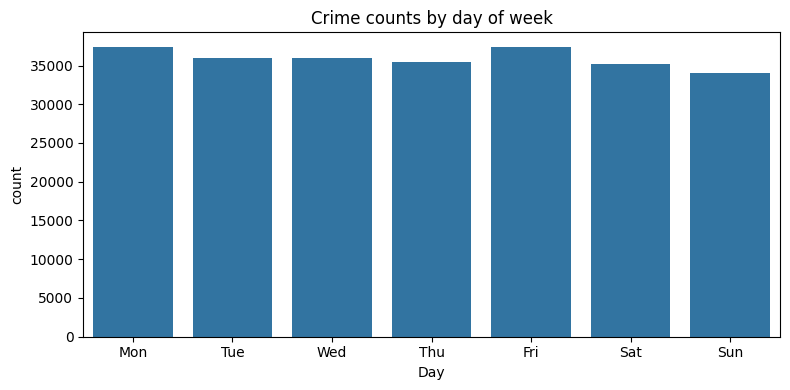

In [23]:
plt.figure(figsize = (8, 4))
day_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
sns.countplot(data = df, x = "Day", order = day_order)
plt.title("Crime counts by day of week")
plt.tight_layout()
plt.savefig("../results/01/crime_counts_by_day.png", dpi = 150, bbox_inches = "tight")
plt.show()

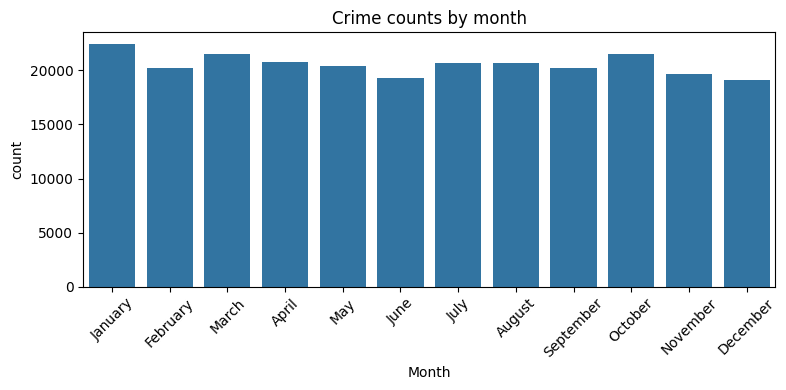

In [24]:
plt.figure(figsize = (8, 4))
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]
sns.countplot(data = df[df["Year"] != 2026], x = "Month", order = month_order)
plt.title("Crime counts by month")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.savefig("../results/01/crime_counts_by_month.png", dpi = 150, bbox_inches = "tight")
plt.show()

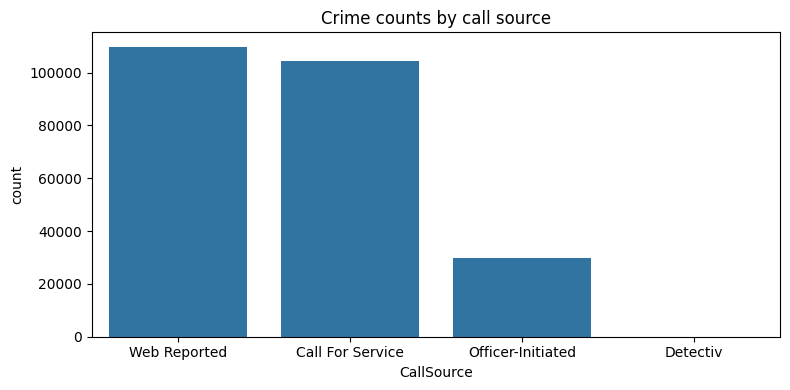

In [25]:
plt.figure(figsize = (8, 4))
order = df["CallSource"].value_counts().index
sns.countplot(data = df, x = "CallSource", order = order)
plt.title("Crime counts by call source")
plt.tight_layout()
plt.savefig("../results/01/crime_counts_by_callsource.png", dpi = 150, bbox_inches = "tight")
plt.show()

In [26]:
print(df["TimeOccur"].value_counts().head(20))
print("\nSample of unique formats:")
print(df["TimeOccur"].dropna().sample(20, random_state=42).tolist())

TimeOccur
00:00    4508
1200     3007
12:00    1993
17:00    1798
2200     1508
18:00    1484
20:00    1463
1700     1454
0000     1417
22:00    1409
1800     1379
21:00    1375
2000     1353
2100     1301
19:00    1233
1900     1193
16:00    1179
2300     1142
1600     1138
15:00    1094
Name: count, dtype: int64

Sample of unique formats:
['1814', '00:26', '1900', '1340', '1100', '18:15', '2306', '2329', '1823', '2024', '2300', '1710', '1719', '2447', '04:30', '07:30', '15:21', '1525', '2230', '1809']
